# Capítulo 22 — Óptica Atmosférica: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | arco-íris: traçado de raios na gota e os 42° | NumPy |
| 2 | halo de 22°: Monte Carlo de cristais de gelo | NumPy |
| 3 | céu azul, pôr do sol vermelho: Rayleigh + Beer | NumPy |
| 4 | miragens: raios curvando no ar quente | `solve_ivp` |

Exercícios numéricos N1–N4 no fim; soluções em `cap22_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## Caso 1 — Arco-íris: por que 42°?

Raio entra na gota (refrata), reflete uma vez dentro, sai (refrata). O desvio total em função do parâmetro de impacto $b = \sin\theta_i$:
$$D(\theta_i) = 180° + 2\theta_i - 4\theta_r,\qquad \sin\theta_i = n\sin\theta_r.$$
O **mínimo** de $D$ concentra os raios (cáustica): o arco brilhante a $180° - D_{min} \approx 42°$ do ponto antissolar — e a dispersão $n(\lambda)$ separa as cores.

vermelho : primario 42.44° | secundario 50.23°
violeta  : primario 40.72° | secundario 53.35°


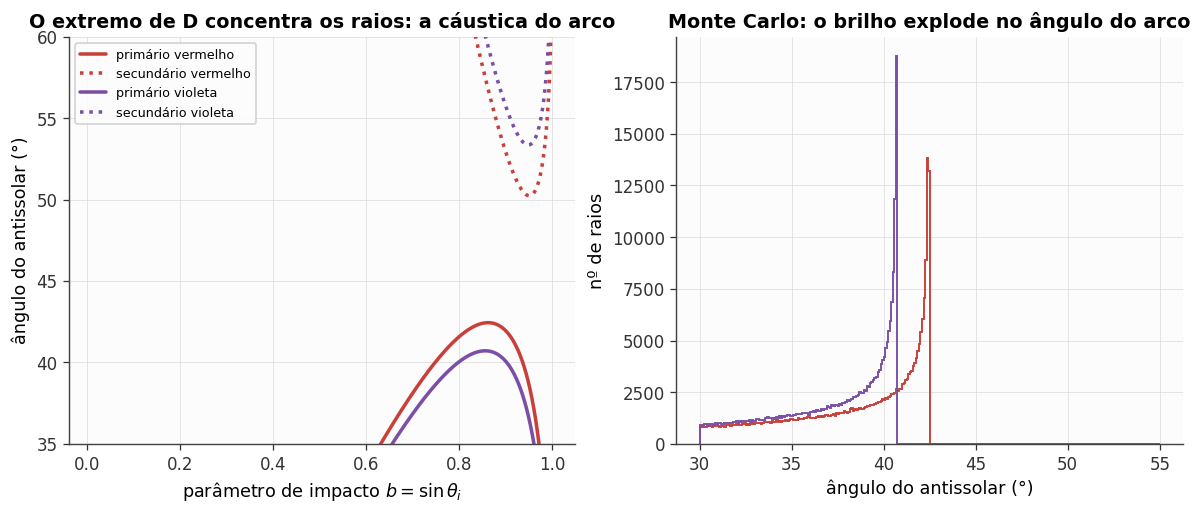


vermelho FORA (42,4°), violeta DENTRO (40,7°); o secundario inverte as
cores (~51°) e entre os dois quase nenhum raio: a banda escura de Alexandre.


In [2]:
def D_primario(theta_i, n):
    theta_r = np.arcsin(np.sin(theta_i)/n)
    return np.pi + 2*theta_i - 4*theta_r

def D_secundario(theta_i, n):
    theta_r = np.arcsin(np.sin(theta_i)/n)
    return 2*np.pi + 2*theta_i - 6*theta_r      # duas reflexões internas

ti = np.linspace(0.01, np.pi/2 - 0.01, 2000)
n_verm, n_viol = 1.3305, 1.3425

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for n, cor, nome in [(n_verm, CORES['vermelho'], 'vermelho'),
                      (n_viol, '#7b4fa6', 'violeta')]:
    ang1 = 180 - np.rad2deg(D_primario(ti, n))   # ângulo em relação ao antissolar
    ang2 = np.rad2deg(D_secundario(ti, n)) - 180
    ax1.plot(np.sin(ti), ang1, color=cor, label=f'primário {nome}')
    ax1.plot(np.sin(ti), ang2, ':', color=cor, label=f'secundário {nome}')
    print(f'{nome:9s}: primario {ang1.max():.2f}° | secundario {ang2.min():.2f}°')
ax1.axhspan(np.rad2deg(np.pi) - 138.2, 53.6, alpha=0)  # noop p/ escala
ax1.set(xlabel='parâmetro de impacto $b = \\sin\\theta_i$',
        ylabel='ângulo do antissolar (°)', ylim=(35, 60),
        title='O extremo de D concentra os raios: a cáustica do arco')
ax1.legend(fontsize=8)

# histograma Monte Carlo: raios uniformes no disco -> concentração no ângulo do arco
rng = np.random.default_rng(42)
b = np.sqrt(rng.uniform(0, 1, 400_000))          # área uniforme
ti_mc = np.arcsin(b)
for n, cor in [(n_verm, CORES['vermelho']), (n_viol, '#7b4fa6')]:
    ang = 180 - np.rad2deg(D_primario(ti_mc, n))
    ax2.hist(ang, bins=300, range=(30, 55), histtype='step', color=cor, lw=1.2)
ax2.set(xlabel='ângulo do antissolar (°)', ylabel='nº de raios',
        title='Monte Carlo: o brilho explode no ângulo do arco')
plt.show()
print('\nvermelho FORA (42,4°), violeta DENTRO (40,7°); o secundario inverte as')
print('cores (~51°) e entre os dois quase nenhum raio: a banda escura de Alexandre.')

## Caso 2 — Halo de 22°: o prisma de gelo

Cristais hexagonais são prismas de $A = 60°$ ($n = 1{,}31$). O desvio tem mínimo
$$\delta_{min} = 2\arcsin\!\left(n\sin\tfrac{A}{2}\right) - A \approx 22°,$$
e cristais orientados ao acaso concentram a luz nesse mínimo: o anel de 22° em volta do Sol.

desvio mínimo teórico: 21.8°


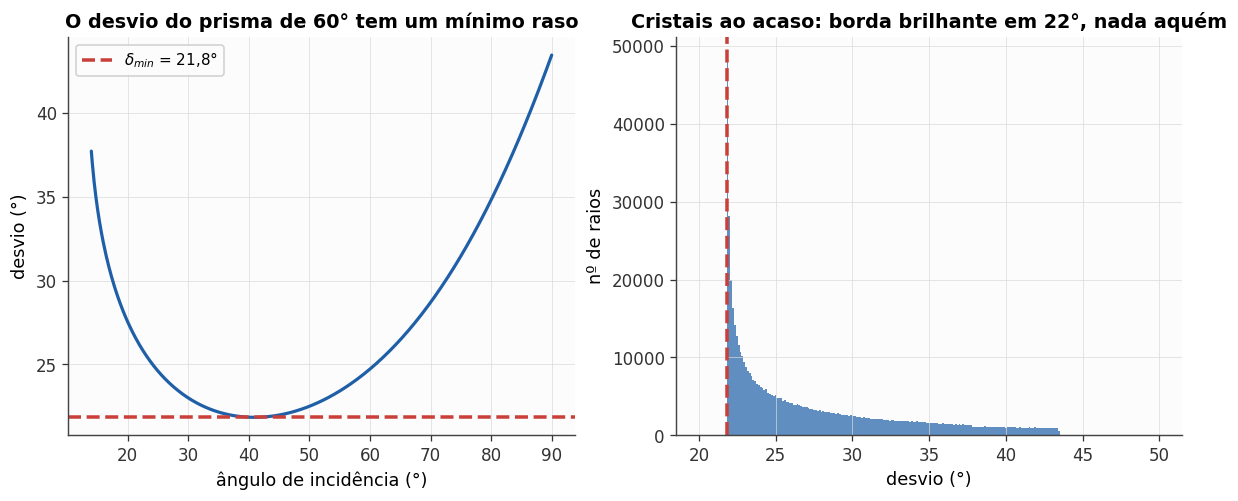

o halo e ESCURO por dentro (nenhum raio desvia menos que o minimo) e tem
borda interna avermelhada (n menor no vermelho -> delta_min menor — N2).
Placas orientadas horizontais concentram nos parelios (sun dogs).


In [3]:
n_gelo, A = 1.31, np.deg2rad(60)
delta_min = 2*np.arcsin(n_gelo*np.sin(A/2)) - A
print(f'desvio mínimo teórico: {np.rad2deg(delta_min):.1f}°')

def desvio(theta1):
    # prisma: refração dupla nas faces alternadas (60°)
    t1r = np.arcsin(np.sin(theta1)/n_gelo)
    t2r = A - t1r
    with np.errstate(invalid='ignore'):
        t2 = np.arcsin(n_gelo*np.sin(t2r))       # NaN = reflexão interna total
    return theta1 + t2 - A

rng = np.random.default_rng(22)
theta1 = rng.uniform(np.deg2rad(14), np.pi/2, 600_000)  # incidências aleatórias
d = np.rad2deg(desvio(theta1))
d = d[np.isfinite(d)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
tt = np.linspace(np.deg2rad(14), np.pi/2, 500)
ax1.plot(np.rad2deg(tt), np.rad2deg(desvio(tt)), color=CORES['azul'], lw=2)
ax1.axhline(np.rad2deg(delta_min), color=CORES['vermelho'], ls='--',
            label=f'$\\delta_{{min}}$ = {np.rad2deg(delta_min):.1f}°'.replace('.', ','))
ax1.set(xlabel='ângulo de incidência (°)', ylabel='desvio (°)',
        title='O desvio do prisma de 60° tem um mínimo raso')
ax1.legend()
ax2.hist(d, bins=250, range=(20, 50), color=CORES['azul'], histtype='stepfilled',
         alpha=0.7)
ax2.axvline(np.rad2deg(delta_min), color=CORES['vermelho'], ls='--')
ax2.set(xlabel='desvio (°)', ylabel='nº de raios',
        title='Cristais ao acaso: borda brilhante em 22°, nada aquém')
plt.show()
print('o halo e ESCURO por dentro (nenhum raio desvia menos que o minimo) e tem')
print('borda interna avermelhada (n menor no vermelho -> delta_min menor — N2).')
print('Placas orientadas horizontais concentram nos parelios (sun dogs).')

## Caso 3 — Céu azul, pôr do sol vermelho

Espalhamento Rayleigh: $\sigma \propto \lambda^{-4}$ (T3). O céu é a luz espalhada (azul vence); o Sol poente é a luz **transmitida** por um caminho $\propto 1/\sin\Psi$ (Beer, Cap. 2) — o azul foi roubado no caminho.

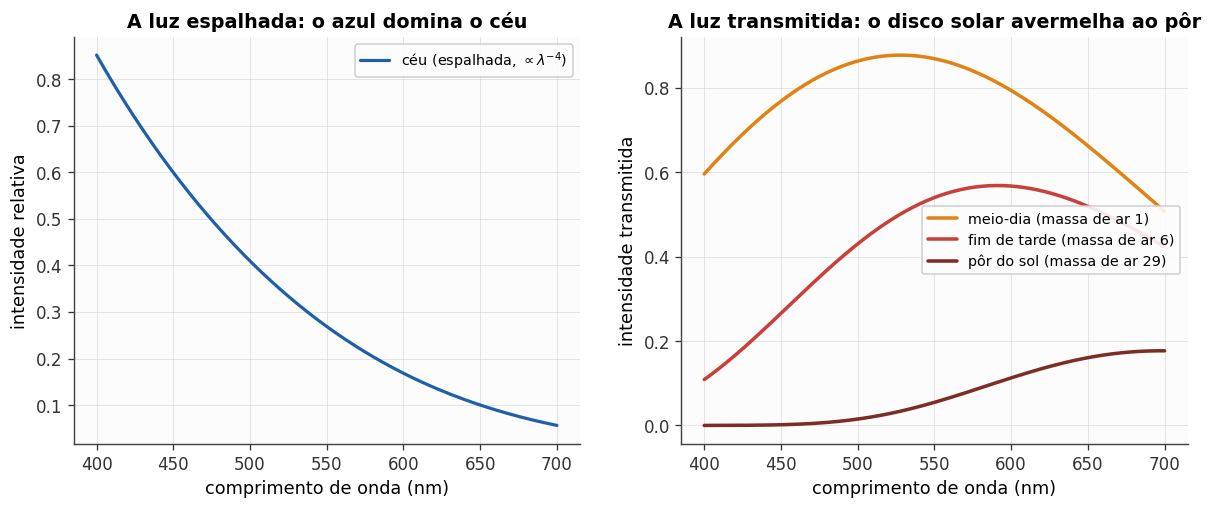

elevação 90°: vermelho/azul transmitido =    1.0
elevação 10°: vermelho/azul transmitido =    2.7
elevação  2°: vermelho/azul transmitido =  162.8

aerossol vulcanico multiplica tau e faz os poentes historicos (N3);
nuvens sao brancas porque gotas >> lambda espalham TODAS as cores (Mie).


In [4]:
lam = np.linspace(0.40, 0.70, 200)              # µm
tau_z = 0.10*(0.55/lam)**4                      # profundidade óptica vertical Rayleigh
S_sol = np.exp(-((lam - 0.50)/0.25)**2)         # espectro solar aproximado

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax1.plot(lam*1000, S_sol*tau_z/tau_z.max(), color=CORES['azul'], lw=2,
         label='céu (espalhada, $\\propto\\lambda^{-4}$)')
ax1.set(xlabel='comprimento de onda (nm)', ylabel='intensidade relativa',
        title='A luz espalhada: o azul domina o céu')
ax1.legend(fontsize=9)

for Psi, cor, nome in [(90, CORES['laranja'], 'meio-dia'),
                        (10, CORES['vermelho'], 'fim de tarde'),
                        (2, '#7b2d26', 'pôr do sol')]:
    m_ar = 1/np.sin(np.deg2rad(Psi))
    T = np.exp(-tau_z*m_ar)
    ax2.plot(lam*1000, S_sol*T, color=cor,
             label=f'{nome} (massa de ar {m_ar:.0f})')
ax2.set(xlabel='comprimento de onda (nm)', ylabel='intensidade transmitida',
        title='A luz transmitida: o disco solar avermelha ao pôr')
ax2.legend(fontsize=9)
plt.show()

for Psi in [90, 10, 2]:
    m_ar = 1/np.sin(np.deg2rad(Psi))
    T = np.exp(-tau_z*m_ar)
    razao = (S_sol*T)[lam > 0.62].sum()/(S_sol*T)[lam < 0.47].sum()
    print(f'elevação {Psi:2.0f}°: vermelho/azul transmitido = {razao:6.1f}')
print('\naerossol vulcanico multiplica tau e faz os poentes historicos (N3);')
print('nuvens sao brancas porque gotas >> lambda espalham TODAS as cores (Mie).')

## Caso 4 — Miragens: o raio que curva

O índice $n$ segue a densidade (ar quente $=$ $n$ menor). Um raio quase horizontal obedece
$$\frac{d^2z}{dx^2} \simeq \frac{1}{n}\frac{dn}{dz}:$$
sobre asfalto quente, $n$ cresce com a altura e o raio curva **para cima** — o 'lago' na estrada é o céu refletido (miragem inferior).

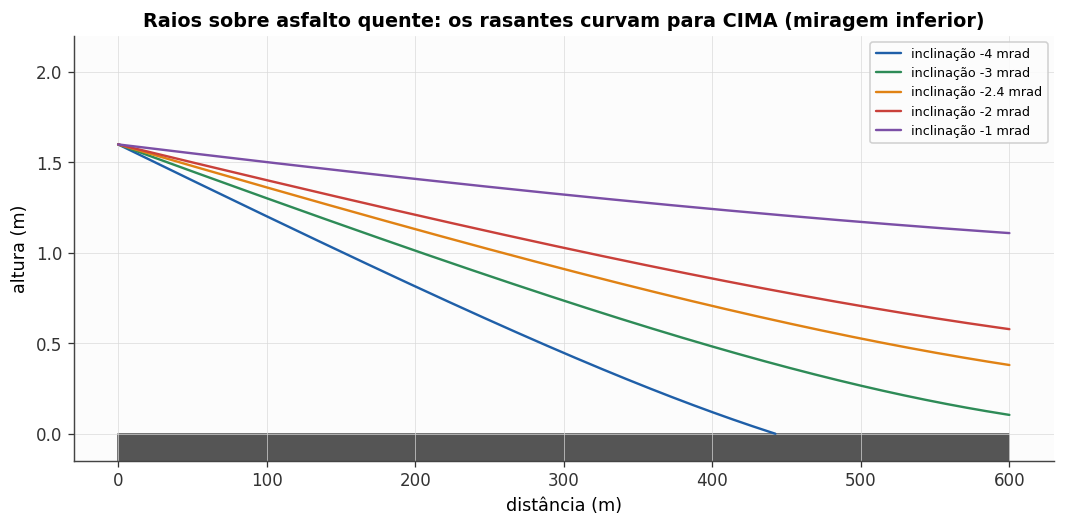

raios rasantes retornam ao olho vindos "do chao": o cerebro ve um espelho
d'agua que e ceu. No frio e o oposto (miragem superior/Fata Morgana): ar
denso embaixo curva o raio para baixo e navios flutuam no horizonte (N4).


In [5]:
# asfalto a +20 K: T(z) = T0 + dT*exp(-z/h): gradiente forte nos primeiros cm
T0, dT_solo, h_esc = 300.0, 20.0, 0.5

def n_de_z(z):
    T = T0 + dT_solo*np.exp(-np.maximum(z, 0)/h_esc)
    return 1 + 79e-6*(288.0/T)                   # n-1 ∝ densidade ∝ 1/T

def dndz(z, dz=1e-4):
    return (n_de_z(z + dz) - n_de_z(z - dz))/(2*dz)

def traça_raio(z0, incl_mrad):
    def rhs(x, y):
        z, p = y                                  # p = dz/dx
        return [p, dndz(z)/n_de_z(z)]
    return solve_ivp(rhs, [0, 600], [z0, incl_mrad*1e-3], max_step=1.0,
                     dense_output=True)

fig, ax = plt.subplots(figsize=(11, 4.8))
xx = np.linspace(0, 600, 500)
for incl, cor in zip([-4, -3, -2.4, -2, -1], 
                      [CORES['azul'], CORES['verde'], CORES['laranja'],
                       CORES['vermelho'], '#7b4fa6']):
    s = traça_raio(1.6, incl)                    # olho do motorista a 1,6 m
    zz = s.sol(xx)[0]
    m = zz > 0
    ax.plot(xx[m], zz[m], color=cor, lw=1.5,
            label=f'inclinação {incl} mrad')
ax.fill_between([0, 600], [0, 0], [-0.15, -0.15], color='#555555')
ax.set(xlabel='distância (m)', ylabel='altura (m)', ylim=(-0.15, 2.2),
       title='Raios sobre asfalto quente: os rasantes curvam para CIMA (miragem inferior)')
ax.legend(fontsize=8)
plt.show()
print('raios rasantes retornam ao olho vindos "do chao": o cerebro ve um espelho')
print('d\'agua que e ceu. No frio e o oposto (miragem superior/Fata Morgana): ar')
print('denso embaixo curva o raio para baixo e navios flutuam no horizonte (N4).')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap22_solucoes.ipynb`**.

**N1** — Com $n(\lambda)$ tabelado para a água (fornecido no enunciado), calcule a largura angular do arco primário (vermelho−violeta) e a posição do secundário; compare com os ~1,8° e ~51° observados.

**N2** — Repita o Monte Carlo do halo para $n$ do vermelho (1,307) e do violeta (1,317) e mostre que a borda interna do halo é avermelhada; calcule a separação angular das cores.

**N3** — Adicione ao Caso 3 uma camada de aerossol vulcânico ($\tau_a$ = 0,1–0,5, cinza espectralmente) e trace a cor do céu no crepúsculo; por que os poentes pós-Pinatubo foram roxos?

**N4** — Inverta o perfil do Caso 4 (mar frio sob ar quente: $T$ crescendo com $z$) e trace os raios: mostre a miragem superior e estime o alcance extra do horizonte ('looming').

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*